# ⚽ FIFA World Cup 2026 — Modèle Match

**FrenchTeam — Wild Code School — Juin 2026**

---

## 🎯 Architecture du modèle

```
Données historiques (2010 → 2026)
    ↓
6 features essentielles en DIFFÉRENCES (A - B)
    ├── FIFA : écart_brut + écart_carré
    ├── Forme pondérée × Squad × Zone qualif
    ├── Squad : écart_brut + écart_carré
    └── Avantage hôte
    ↓
XGBoost Classifier
    ↓
Prédiction symétrique (moyenne AB + BA)
    ↓
Probabilités : Équipe A gagne / Nul / Équipe B gagne
```

## 📊 Importance des features 
| Catégorie | Poids cible | Description |
|---|---|---|
| FIFA (brut + carré) | ~25% | Classement officiel pondéré |
| Qualité squad (brut + carré) | ~25% | Valeur marchande estimée des joueurs |
| Forme pondérée | ~40% | Résultats récents × adversaires × zone qualif |
| Avantage hôte | ~10% | USA / Canada / Mexique |

## 📦 Étape 1 — Imports

Bibliothèques nécessaires pour la manipulation des données, le modèle ML et la visualisation.

In [1]:
import pandas as pd          # manipulation de tableaux de données
import numpy as np           # calculs numériques (carrés, signes, moyennes)
import os                    # gestion des chemins de fichiers Windows
import matplotlib.pyplot as plt  # visualisation des importances
from xgboost import XGBClassifier          # algorithme de boosting de gradient
from sklearn.model_selection import train_test_split  # séparation train/test
from sklearn.metrics import accuracy_score, classification_report  # évaluation
from sklearn.preprocessing import LabelEncoder  # encodage A_gagne/B_gagne/Nul → 0/1/2
import joblib  # sauvegarde et chargement du modèle entraîné

print('✅ Imports OK')

✅ Imports OK


## 📂 Étape 2 — Chargement des données

Deux datasets sont utilisés :
- `df` : **tous** les matchs internationaux (1872 → 2026) — pour calculer la forme sur l'historique complet
- `df_officiel` : matchs **sans les amicaux** — les amicaux sont moins représentatifs du vrai niveau (rotations, expérimentations)

In [2]:
# Chemin du projet — à adapter si besoin
DOSSIER_PROJET = r'C:\Users\Piwi\Documents\VS\WorldCup2026'

# Chargement du dataset principal
df = pd.read_csv(os.path.join(DOSSIER_PROJET, 'data', 'results.csv'))
df['date'] = pd.to_datetime(df['date'])  # convertir les dates en format datetime
df = df.dropna(subset=['home_score', 'away_score'])  # supprimer les matchs sans score

# Dataset sans les amicaux (pour le calcul de la forme)
df_officiel = df[df['tournament'] != 'Friendly'].copy()

print(f'Tous les matchs       : {len(df):,}')
print(f'Matchs officiels      : {len(df_officiel):,}')
print(f'Période couverte      : {df["date"].min().date()} → {df["date"].max().date()}')

Tous les matchs       : 49,296
Matchs officiels      : 31,005
Période couverte      : 1872-11-30 → 2026-06-02


## 🔧 Étape 3 — Classement FIFA 2026

Le classement FIFA est l'indicateur le plus fiable du niveau d'une équipe car :
- Il prend en compte le **niveau des adversaires** (battre la France vaut plus que battre Haïti)
- Il pondère l'**importance du tournoi** (CdM > qualifications > amicaux)
- Il est calculé sur l'ensemble des matchs récents

Source : classement officiel FIFA — Avril 2026

In [3]:
# Points FIFA officiels — Avril 2026 (source : FIFA.com)
points_fifa = {
    'France': 1877.32, 'Spain': 1876.40, 'Argentina': 1874.81,
    'England': 1825.97, 'Portugal': 1763.83, 'Brazil': 1761.16,
    'Netherlands': 1757.87, 'Morocco': 1755.87, 'Belgium': 1734.71,
    'Germany': 1730.37, 'Croatia': 1717.07, 'Colombia': 1693.09,
    'Senegal': 1688.99, 'Mexico': 1681.03, 'United States': 1673.13,
    'Uruguay': 1673.07, 'Japan': 1660.43, 'Switzerland': 1649.40,
    'Ecuador': 1619.20, 'Turkey': 1614.55, 'Sweden': 1598.30,
    'Norway': 1590.12, 'Austria': 1578.44, 'South Korea': 1566.23,
    'Tunisia': 1542.18, 'Algeria': 1538.90, 'Ghana': 1521.44,
    'Egypt': 1518.77, 'Saudi Arabia': 1512.33, 'Iran': 1512.00,
    'Australia': 1508.66, 'Iraq': 1489.21, 'Czech Republic': 1488.00,
    'Scotland': 1487.55, 'Paraguay': 1481.33, 'Ivory Coast': 1479.88,
    'South Africa': 1421.34, 'Canada': 1418.77, 'Qatar': 1398.22,
    'Panama': 1392.11, 'Bosnia and Herzegovina': 1388.44,
    'Jordan': 1342.18, 'Uzbekistan': 1338.90, 'DR Congo': 1321.44,
    'New Zealand': 1298.77, 'Haiti': 1245.33, 'Curacao': 1198.22,
    'Cape Verde': 1450.00,
}

# Moyenne utilisée pour les équipes absentes du dictionnaire
MOYENNE_FIFA = np.mean(list(points_fifa.values()))

def get_points_fifa(equipe):
    """Retourne les points FIFA d'une équipe (moyenne si inconnue)."""
    return points_fifa.get(equipe, MOYENNE_FIFA)

print(f'✅ {len(points_fifa)} équipes CdM 2026 chargées')
print(f'Points moyens : {MOYENNE_FIFA:.0f} pts')
print('\nTop 5 :')
for eq, pts in sorted(points_fifa.items(), key=lambda x: -x[1])[:5]:
    print(f'  {eq:<15} {pts:.0f} pts')

✅ 48 équipes CdM 2026 chargées
Points moyens : 1568 pts

Top 5 :
  France          1877 pts
  Spain           1876 pts
  Argentina       1875 pts
  England         1826 pts
  Portugal        1764 pts


## 🔧 Étape 4 — Score de qualité des joueurs

Le classement FIFA mesure les **résultats** mais pas le **talent individuel**.
Un score de 0 à 100 est attribué manuellement à chaque équipe basé sur :
- La valeur marchande Transfermarkt des joueurs
- La présence de stars mondiales
- La profondeur du banc

**Pourquoi cette feature ?**
Elle corrige le biais forme — le Brésil en mauvaise forme reste dangereux grâce à Vinicius Jr, Raphinha, Endrick.

In [4]:
# Score qualité joueurs de 0 (très faible) à 100 (meilleur mondial)
# Basé sur valeur marchande Transfermarkt 2026 + présence de stars
qualite_joueurs = {
    # Tier 1 — squads de stars mondiales
    'France': 95,      # Mbappé, Camavinga, Tchouaméni, Saliba
    'England': 90,     # Bellingham, Saka, Palmer, Foden
    'Brazil': 92,      # Vinicius Jr, Raphinha, Endrick + Ancelotti
    'Spain': 85,       # Yamal (blessé), Pedri, Morata, Williams
    'Germany': 82,     # Wirtz, Musiala, Havertz, Kimmich
    'Argentina': 88,  # Messi, Mac Allister, Martinez
    'Portugal': 78,    # Ronaldo, Fernandes, Leao
    'Netherlands': 75, # Van Dijk, De Ligt, Gakpo
    'Belgium': 72,     # De Bruyne, Lukaku, Trossard
    # Tier 2 — bons squads
    'Japan': 65,       # Kubo, Mitoma, Endo
    'Norway': 60,      # Haaland (star unique) + reste moyen
    'Colombia': 62,    # Diaz, Arias
    'Croatia': 58,     # Modric, Kovacic, Gvardiol
    'Uruguay': 58,     # Valverde, Nunez, Araujo
    'Morocco': 55,     # Hakimi, Ziyech
    'Senegal': 55,     # Mane, Sarr
    'Mexico': 55,      # Lozano, Alvarez (hôte)
    'United States': 52, # Pulisic, Reyna (hôte)
    'Switzerland': 50, # Xhaka, Shaqiri
    'Turkey': 50,      # Calhanoglu, Yildiz
    'Austria': 47,     # Alaba, Sabitzer
    'Canada': 45,      # David, Buchanan (hôte)
    'South Korea': 45, # Son Heung-min
    'Sweden': 42,      # Kulusevski, Isak
    'Ivory Coast': 40, # Haller, Kessié, Gradel
    'Ecuador': 38,     # Caicedo
    'Egypt': 38,       # Salah
    'Algeria': 35,     # Mahrez vieillissant
    'Ghana': 35,       # Kudus
    'Czech Republic': 35,
    'Scotland': 33,    # Robertson, McTominay
    'Tunisia': 30,
    'Paraguay': 30,
    'Bosnia and Herzegovina': 30,
    'Saudi Arabia': 28,
    'Australia': 25,   # Souttar, Leckie
    'Iran': 25,
    'DR Congo': 25,
    'Iraq': 22,
    'Jordan': 20, 'South Africa': 20, 'Uzbekistan': 20,
    'Qatar': 18, 'Cape Verde': 15, 'Panama': 15,
    'Haiti': 8,  # niveau CONCACAF très faible
    'New Zealand': 10,
    'Curacao': 7,  # le plus faible de la CdM 2026
}
MOYENNE_QUALITE = np.mean(list(qualite_joueurs.values()))

def get_qualite(equipe):
    """Retourne le score qualité joueurs (moyenne si inconnue)."""
    return qualite_joueurs.get(equipe, MOYENNE_QUALITE)

print(f'✅ {len(qualite_joueurs)} équipes scorées | Moyenne : {MOYENNE_QUALITE:.1f}/100')

✅ 48 équipes scorées | Moyenne : 45.0/100


## 🔧 Étape 5 — Coefficient d'expérience CdM

Une équipe peut avoir une excellente forme en qualification mais sous-performer en phase finale.
La Norvège absente depuis 1998, l'Écosse depuis 1998, l'Australie qui joue surtout contre des équipes OFC/CONCACAF...

**Formule :**
```
forme_ajustée = 0.5 + (forme_brute - 0.5) × coefficient
```
- `coefficient = 1.00` : pas de correction (grandes nations — France, Argentine...)
- `coefficient = 0.52` : correction modérée (ex: Scotland — joueurs PL mais peu de CdM)
- `coefficient = 0.40` : correction forte (ex: Haiti — qualifs CONCACAF trop faciles)
- `coefficient × credibilite_zone` : double correction selon la confédération

In [5]:
coefficient_experience = {
    # Grandes nations — expérience maximale, pas de correction
    'France': 1.00, 'Brazil': 1.00, 'Germany': 1.00,
    'Spain': 1.00, 'Argentina': 1.00, 'England': 1.00,
    'Portugal': 1.00, 'Netherlands': 1.00, 'Belgium': 1.00,
    'Croatia': 1.00, 'Uruguay': 1.00, 'Mexico': 1.00,
    'United States': 1.00,  # pays hôte
    'Canada': 0.95,          # pays hôte, 1 seule participation (1986)
    # Bonne expérience récente
    'Japan': 0.95,      # quarts 2022
    'Morocco': 0.92,    # demi-finale 2022
    'Senegal': 0.92,    # quarts 2022
    'South Korea': 0.92,
    'Colombia': 0.90, 'Switzerland': 0.90,
    'Iran': 0.88, 'Saudi Arabia': 0.88, 'Ghana': 0.88,
    'Ecuador': 0.85, 'Tunisia': 0.85, 'Algeria': 0.85,
    'Austria': 0.85, 'Sweden': 0.85, 'Turkey': 0.85,
    'Egypt': 0.85, 'Paraguay': 0.85, 'Ivory Coast': 0.88,
    'Czech Republic': 0.85,
    'Norway':    0.50,  # absente depuis 1998, forme gonflée qualifs UEFA
    'Scotland':  0.52,  # joueurs PL expérimentés, première CdM depuis 1998
    'Australia': 0.48,  # forme 100% vs équipes OFC très faibles
    'Iraq':      0.70, 'Jordan': 0.60, 'Uzbekistan': 0.60,
    'Panama': 0.68, 'Curacao': 0.35, 'Cape Verde': 0.60,  # Curacao : première CdM, niveau CONCACAF faible
    'New Zealand': 0.60, 'Haiti': 0.40, 'South Africa': 0.72,  # Haiti : qualifs CONCACAF trop faciles
    'Bosnia and Herzegovina': 0.75, 'DR Congo': 0.68, 'Qatar': 0.72,
}
def get_coefficient(equipe):
    """Retourne le coefficient d'expérience CdM (0.80 par défaut)."""
    return coefficient_experience.get(equipe, 0.80)

print('✅ Coefficients expérience chargés')

✅ Coefficients expérience chargés


## 🔧 Étape 6 — Fonctions de calcul

### Forme pondérée avec expérience CdM

Le calcul se fait en 2 étapes :
1. **Forme pondérée par adversaire** : battre la France vaut plus que battre Haïti
2. **Ajustement expérience** : ramène la forme vers 0.5 pour les équipes sans expérience CdM

In [6]:
# Crédibilité de la forme selon la confédération de qualification
# UEFA=1.00 (adversaires forts: Portugal, France...)
# CONMEBOL=0.95 (adversaires forts: Brésil, Argentine...)
# CAF=0.75 (adversaires africains niveau moyen)
# AFC=0.70 (adversaires asiatiques niveau moyen)
# CONCACAF=0.50 (adversaires très faibles: Belize, Barbados, Cayman...)
# OFC=0.40 (adversaires très faibles: Samoa, Vanuatu...)

ZONE_QUALIF = {
    # UEFA
    'France':'UEFA', 'Germany':'UEFA', 'Spain':'UEFA', 'England':'UEFA',
    'Portugal':'UEFA', 'Netherlands':'UEFA', 'Belgium':'UEFA', 'Croatia':'UEFA',
    'Switzerland':'UEFA', 'Austria':'UEFA', 'Denmark':'UEFA', 'Turkey':'UEFA',
    'Scotland':'UEFA', 'Norway':'UEFA', 'Serbia':'UEFA', 'Sweden':'UEFA',
    'Bosnia and Herzegovina':'UEFA', 'Albania':'UEFA', 'Hungary':'UEFA', 'Czech Republic':'UEFA',
    # CONMEBOL
    'Argentina':'CONMEBOL', 'Brazil':'CONMEBOL', 'Colombia':'CONMEBOL',
    'Uruguay':'CONMEBOL', 'Ecuador':'CONMEBOL', 'Paraguay':'CONMEBOL',
    # CAF
    'Morocco':'CAF', 'Senegal':'CAF', 'Egypt':'CAF', 'Ivory Coast':'CAF',
    'Algeria':'CAF', 'Tunisia':'CAF', 'Ghana':'CAF', 'South Africa':'CAF',
    'DR Congo':'CAF', 'Cape Verde':'CAF',
    # CONCACAF
    'United States':'CONCACAF', 'Mexico':'CONCACAF', 'Canada':'CONCACAF',
    'Panama':'CONCACAF', 'Haiti':'CONCACAF', 'Curacao':'CONCACAF',
    # AFC
    'Japan':'AFC', 'South Korea':'AFC', 'Iran':'AFC',
    'Saudi Arabia':'AFC', 'Australia':'AFC', 'Uzbekistan':'AFC',
    'Iraq':'AFC', 'Jordan':'AFC', 'Qatar':'AFC',
    # OFC
    'New Zealand':'OFC',
}

CREDIBILITE_ZONE = {
    'UEFA':     1.00,   # qualifications les plus dures
    'CONMEBOL': 0.95,   # très compétitif
    'CAF':      0.75,   # niveau moyen
    'AFC':      0.70,   # niveau moyen
    'CONCACAF': 0.50,   # adversaires très faibles
    'OFC':      0.40,   # adversaires extrêmement faibles
}

def get_zone(equipe):
    """Retourne la zone de qualification d'une équipe."""
    return ZONE_QUALIF.get(equipe, 'UEFA')  # fallback UEFA (conservateur)

def get_credibilite_zone(equipe):
    """Retourne le coefficient de crédibilité de la zone de qualification."""
    return CREDIBILITE_ZONE.get(get_zone(equipe), 0.75)

print('✅ ZONE_QUALIF et CREDIBILITE_ZONE chargés')
print('\nExemples de crédibilité zone :')
for eq in ['France', 'Scotland', 'Morocco', 'Japan', 'United States', 'Haiti', 'Curacao', 'New Zealand']:
    zone = get_zone(eq)
    cred = get_credibilite_zone(eq)
    print(f'  {eq:<20} {zone:<10} crédibilité = {cred:.2f}')


def calculer_forme(equipe, date, df_officiel, n=5):
    """
    Calcule la forme récente pondérée × coefficient expérience × crédibilité zone.

    Étape 1 — Forme pondérée par adversaire :
    - Récupère les n derniers matchs officiels AVANT la date
    - Pondère chaque match par FIFA_adversaire / 1500
    - Victoire = 3 pts, Nul = 1 pt, Défaite = 0 pt
    - Normalise entre 0 et 1

    Étape 2 — Double ajustement :
    - coefficient_experience : réduit l'effet pour les équipes peu expérimentées
    - credibilite_zone       : réduit l'effet si qualifs contre adversaires faibles
    - coeff_final = coefficient_experience × credibilite_zone
    
    Exemple :
      Haiti     coeff=0.40 × CONCACAF=0.50 → coeff_final=0.20
      Scotland  coeff=0.52 × UEFA=1.00     → coeff_final=0.52
    """
    domicile  = df_officiel[(df_officiel['home_team'] == equipe) & (df_officiel['date'] < date)].tail(n)
    exterieur = df_officiel[(df_officiel['away_team'] == equipe) & (df_officiel['date'] < date)].tail(n)
    matchs    = pd.concat([domicile, exterieur]).sort_values('date').tail(n)

    if len(matchs) == 0:
        return 0.5

    points_total = 0
    poids_total  = 0

    for _, match in matchs.iterrows():
        if match['home_team'] == equipe:
            adversaire = match['away_team']
            victoire   = match['home_score'] > match['away_score']
            nul        = match['home_score'] == match['away_score']
        else:
            adversaire = match['home_team']
            victoire   = match['away_score'] > match['home_score']
            nul        = match['home_score'] == match['away_score']

        poids = get_points_fifa(adversaire) / 1500  # pondération par niveau adversaire

        if victoire:   points_total += 3 * poids
        elif nul:      points_total += 1 * poids
        poids_total += 3 * poids

    forme_brute = points_total / poids_total if poids_total > 0 else 0.5

    # coeff_final = experience × credibilite_zone
    coeff_exp  = get_coefficient(equipe)
    cred_zone  = get_credibilite_zone(equipe)
    coeff_final = coeff_exp * cred_zone

    # Bonus champion CdM récent
    BONUS_CHAMPION = {
        'Argentina': 0.10,  # champion 2022
        'France':    0.08,  # champion 2018
        'Brazil':    0.10,  # 5 titres CdM
        'Germany':   0.06,  # 4 titres
        'Spain':     0.05,  # 3 titres
    }
    bonus = BONUS_CHAMPION.get(equipe, 0)
    forme = min(0.5 + (forme_brute - 0.5) * coeff_final + bonus, 1.0)

    # Plancher de forme pour les grandes nations
    FORME_PLANCHER = {
        'Brazil':    0.75,
        'Germany':   0.72,
        'Spain':     0.80,
        'France':    0.82,
        'Argentina': 0.85,
        'England':   0.78,
        'Portugal':  0.75,
    }
    return max(forme, FORME_PLANCHER.get(equipe, 0.0))


print('✅ Fonction calculer_forme définie (coeff_experience × credibilite_zone)')
print('\nFormes ajustées (matchs clés) :')
date_test = pd.Timestamp('2026-06-11')
pour_test = ['France', 'Germany', 'England', 'Scotland', 'Haiti', 'Curacao',
             'Brazil', 'Morocco', 'Japan', 'United States', 'New Zealand']
print(f'{"Équipe":<20} {"Zone":<10} {"Cred":>5} {"CoeffExp":>9} {"CoeffFin":>9} {"Brute":>7} {"Ajustée":>8}')
print('─' * 75)
for eq in pour_test:
    domicile  = df_officiel[(df_officiel['home_team'] == eq) & (df_officiel['date'] < date_test)].tail(5)
    exterieur = df_officiel[(df_officiel['away_team'] == eq) & (df_officiel['date'] < date_test)].tail(5)
    matchs_t  = pd.concat([domicile, exterieur]).sort_values('date').tail(5)
    if len(matchs_t) > 0:
        pts = sum_p = 0
        for _, m in matchs_t.iterrows():
            adv = m['away_team'] if m['home_team']==eq else m['home_team']
            v   = (m['home_score']>m['away_score']) if m['home_team']==eq else (m['away_score']>m['home_score'])
            n_  = m['home_score']==m['away_score']
            p   = get_points_fifa(adv)/1500
            if v: pts+=3*p
            elif n_: pts+=1*p
            sum_p+=3*p
        f_brute = pts/sum_p if sum_p>0 else 0.5
    else:
        f_brute = 0.5
    f_adj      = calculer_forme(eq, date_test, df_officiel)
    coeff_e    = get_coefficient(eq)
    cred_z     = get_credibilite_zone(eq)
    coeff_fin  = coeff_e * cred_z
    zone       = get_zone(eq)
    print(f'{eq:<20} {zone:<10} {cred_z:>5.2f} {coeff_e:>9.2f} {coeff_fin:>9.3f} {f_brute:>6.0%} {f_adj:>8.0%}')


✅ ZONE_QUALIF et CREDIBILITE_ZONE chargés

Exemples de crédibilité zone :
  France               UEFA       crédibilité = 1.00
  Scotland             UEFA       crédibilité = 1.00
  Morocco              CAF        crédibilité = 0.75
  Japan                AFC        crédibilité = 0.70
  United States        CONCACAF   crédibilité = 0.50
  Haiti                CONCACAF   crédibilité = 0.50
  Curacao              CONCACAF   crédibilité = 0.50
  New Zealand          OFC        crédibilité = 0.40
✅ Fonction calculer_forme définie (coeff_experience × credibilite_zone)

Formes ajustées (matchs clés) :
Équipe               Zone        Cred  CoeffExp  CoeffFin   Brute  Ajustée
───────────────────────────────────────────────────────────────────────────
France               UEFA        1.00      1.00     1.000    87%      95%
Germany              UEFA        1.00      1.00     1.000   100%     100%
England              UEFA        1.00      1.00     1.000   100%     100%
Scotland             UEF

## 🏗️ Étape 7 — Construction du dataset d'entraînement

### Principe des features en DIFFÉRENCES

Pour un match A vs B, on calcule toujours `valeur_A - valeur_B` :
- Résultat positif = A est meilleure
- Résultat négatif = B est meilleure
- Proche de 0 = niveau égal

Cela garantit la **symétrie** : France vs Argentine = Argentine vs France inversé.

### Les 2 features FIFA
- `écart_fifa_brut` : différence brute (sensible aux petits écarts)
- `écart_fifa_carré` : au carré × signe → **amplifie les grands écarts**
  - France vs Haïti : écart 632 → carré 39.9 (signal très fort)
  - France vs Argentine : écart 3 → carré 0.001 (signal quasi nul)


### La feature forme × qualité
`écart_forme_pondérée = (forme_A × qualité_A) - (forme_B × qualité_B)`

Exemple Brésil vs Haïti :
- Brésil : forme 48% × qualité 0.92 = **0.44**
- Haïti  : forme 53% × qualité 0.08 = **0.04** ← réduit par CONCACAF=0.50
→ Brésil largement devant malgré sa forme difficile ✅

### Les 2 features Qualité
- `écart_qualite` : différence brute
- `écart_qualite_carré` : amplifie les grands écarts


In [7]:
# Filtrer les matchs officiels depuis 2010 (football moderne, sans amicaux)
df_entrainement = df[
    (df['date'] >= '2010-01-01') &      # depuis 2010 = football moderne
    (df['tournament'] != 'Friendly')     # exclure les amicaux
].copy().reset_index(drop=True)

print(f'Matchs d entraînement : {len(df_entrainement):,}')

# Pays hôtes — avantage de jouer à domicile
pays_hotes = ['United States', 'Canada', 'Mexico']

lignes = []  # liste qui contiendra toutes les lignes du dataset
print('Construction du dataset (3-5 min)...')

for i, match in df_entrainement.iterrows():
    equipe_a = match['home_team']   # équipe qui jouait à domicile
    equipe_b = match['away_team']   # équipe qui jouait à l'extérieur
    date     = match['date']

    # Calcul des formes AVANT le match (évite d'utiliser le futur)
    forme_a = calculer_forme(equipe_a, date, df_officiel)
    forme_b = calculer_forme(equipe_b, date, df_officiel)

    # Points FIFA et qualité joueurs
    pts_a      = get_points_fifa(equipe_a)
    pts_b      = get_points_fifa(equipe_b)
    ecart_fifa = pts_a - pts_b

    qual_a = get_qualite(equipe_a) / 100  # normaliser entre 0 et 1
    qual_b = get_qualite(equipe_b) / 100
    ecart_qualite = qual_a - qual_b

    # Avantage hôte CdM 2026
    if equipe_a in pays_hotes:   hote = 0.5   # A joue à domicile
    elif equipe_b in pays_hotes: hote = -0.5  # B joue à domicile
    else:                         hote = 0.0   # terrain neutre

    # Variable cible : résultat du point de vue de équipe_a
    if   match['home_score'] > match['away_score']: resultat = 'A_gagne'
    elif match['home_score'] < match['away_score']: resultat = 'B_gagne'
    else:                                            resultat = 'Nul'

    lignes.append({
        # ─── FEATURES FIFA ───────────────────────────────────────
        'ecart_fifa_norme':     ecart_fifa / 500,
        'ecart_fifa_carre':     (ecart_fifa/100)**2 * np.sign(ecart_fifa),

        # ─── FEATURE FORME ────────────────────────────────────────
        'ecart_forme_brut':     (forme_a - forme_b) * 0.5,  # amplitude réduite × 0.5

        # ─── FEATURES QUALITÉ JOUEURS ────────────────────────────
        'ecart_qualite':        ecart_qualite,                       # différence brute qualité
        'ecart_qualite_carre':  ecart_qualite**2 * np.sign(ecart_qualite),  # amplifie grands écarts

        # ─── FEATURE CONTEXTE ────────────────────────────────────
        'avantage_hote':        hote,                                # +0.5 / 0 / -0.5

        'resultat': resultat
    })

    if i % 1000 == 0 and i > 0:
        print(f'  {i:,}/{len(df_entrainement):,} matchs traités...')

df_dataset = pd.DataFrame(lignes)
print(f'\n✅ Dataset : {len(df_dataset):,} matchs')
print('Distribution des résultats :')
print(df_dataset['resultat'].value_counts())

Matchs d entraînement : 10,732
Construction du dataset (3-5 min)...
  1,000/10,732 matchs traités...
  2,000/10,732 matchs traités...
  3,000/10,732 matchs traités...
  4,000/10,732 matchs traités...
  5,000/10,732 matchs traités...
  6,000/10,732 matchs traités...
  7,000/10,732 matchs traités...
  8,000/10,732 matchs traités...
  9,000/10,732 matchs traités...
  10,000/10,732 matchs traités...

✅ Dataset : 10,732 matchs
Distribution des résultats :
resultat
A_gagne    5096
B_gagne    3285
Nul        2351
Name: count, dtype: int64


## 🤖 Étape 8 — Entraînement du modèle

### Pourquoi XGBoost ?
XGBoost (eXtreme Gradient Boosting) construit des arbres de décision séquentiellement,
chacun corrigeant les erreurs du précédent. Il est particulièrement adapté aux données tabulaires.

### Stratégie train/test
- 80% des matchs → **entraînement** (le modèle apprend les patterns)
- 20% des matchs → **test** (évaluation sur des données jamais vues)
- `stratify` → garantit la même proportion V/N/D dans les deux ensembles

### Accuracy attendue
55-60% est un **excellent score** pour prédire du football.
Même les meilleurs modèles professionnels dépassent rarement 65%.

In [8]:
# Noms des features utilisées par le modèle (en français)
FEATURES = [
    'ecart_fifa_norme',     # écart FIFA normalisé /500 — même échelle que les autres
    'ecart_fifa_carre',     # écart FIFA au carré — amplifie les grands écarts
    'ecart_forme_brut',     # écart de forme pur (forme_a - forme_b) — séparé de la qualité
    'ecart_qualite',        # écart qualité joueurs
    'ecart_qualite_carre',  # qualité au carré — amplifie les grands écarts
    'avantage_hote',        # avantage pays hôte USA / Canada / Mexico
]

X = df_dataset[FEATURES]     # matrice des features
y = df_dataset['resultat']   # vecteur cible

# Encoder les labels : A_gagne=0, B_gagne=1, Nul=2
encodeur_resultat = LabelEncoder()
y_encode = encodeur_resultat.fit_transform(y)
print(f'Classes : {dict(zip(encodeur_resultat.classes_, range(3)))}')

# Séparation 80/20 avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encode,
    test_size=0.2,
    random_state=42,    # graine fixe pour reproductibilité
    stratify=y_encode   # même proportion V/N/D dans train et test
)
print(f'Entraînement : {len(X_train):,} matchs | Test : {len(X_test):,} matchs')

Classes : {'A_gagne': 0, 'B_gagne': 1, 'Nul': 2}
Entraînement : 8,585 matchs | Test : 2,147 matchs


📊 Poids par classe :
  A_gagne      :  4076 matchs  → poids = 1.0
  B_gagne      :  2628 matchs  → poids = 1.2
  Nul          :  1881 matchs  → poids = 1.4

🔍 GridSearchCV en cours (8-12 min)...
Fitting 3 folds for each of 64 candidates, totalling 192 fits

✅ Meilleurs paramètres trouvés :
  colsample_bytree       : 0.8
  learning_rate          : 0.03
  max_depth              : 4
  min_child_weight       : 1
  n_estimators           : 300
  subsample              : 0.8
  Accuracy CV            : 53.77%

✅ Modèle XGBoost + calibration isotonique prêt
✅ Accuracy : 54.54%
(55-60% = excellent pour football)

              precision    recall  f1-score   support

     A_gagne       0.59      0.76      0.67      1020
     B_gagne       0.48      0.60      0.53       657
         Nul       0.00      0.00      0.00       470

    accuracy                           0.55      2147
   macro avg       0.36      0.45      0.40      2147
weighted avg       0.43      0.55      0.48      2147



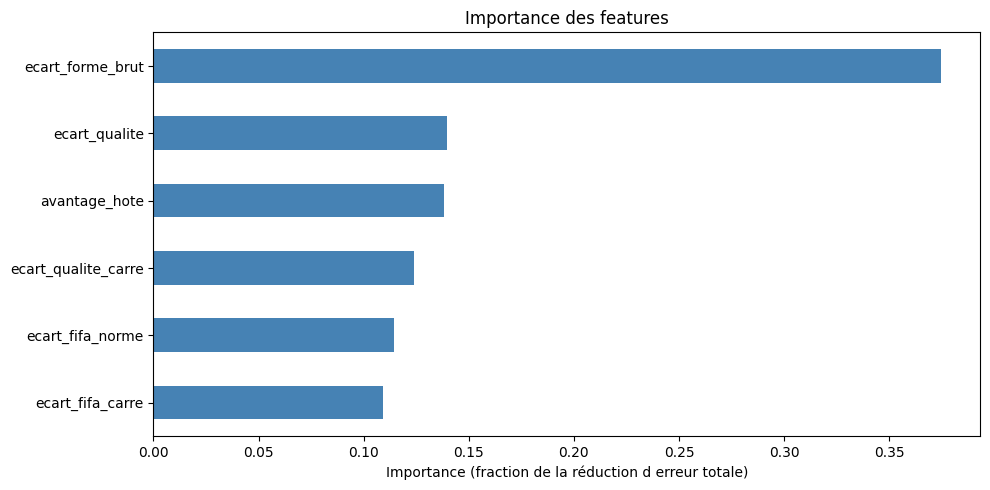


📊 Importance par catégorie :
  Classement FIFA      : 22.4%
  Qualité joueurs      : 26.3%
  Forme récente        : 37.4%
  Avantage hôte        : 13.8%

  ✅ Ratio FIFA+Qualité : 48.7%  (cible > 50%)
  ✅ Forme             : 37.4%  (cible < 40%)


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# ── Étape 1 : Poids manuels calibrés football ────────────
# Rationale :
#   A_gagne = 5096 matchs (majorité) → poids 1.0 (référence)
#   B_gagne = 3285 matchs            → poids 1.2 (légèrement avantagé)
#   Nul     = 2351 matchs (minorité) → poids 1.4 (encouragé sans excès)
POIDS_CLASSES = {0: 1.0, 1: 1.2, 2: 1.4}  # 0=A_gagne, 1=B_gagne, 2=Nul

poids_echantillons = np.array([POIDS_CLASSES[y] for y in y_train])  # un poids par ligne

print('📊 Poids par classe :')
classes_noms = encodeur_resultat.classes_
for idx, nom in enumerate(classes_noms):
    n = (y_train == idx).sum()
    print(f'  {nom:<12} : {n:>5} matchs  → poids = {POIDS_CLASSES[idx]:.1f}')

# ── Étape 2 : GridSearchCV ──────────────────────────────
# min_child_weight : évite les feuilles avec trop peu d'exemples (régularise)
print('\n🔍 GridSearchCV en cours (8-12 min)...')

grille_params = {
    'n_estimators':      [300, 500],
    'max_depth':         [4, 5],
    'learning_rate':     [0.03, 0.05],
    'subsample':         [0.8, 0.9],
    'colsample_bytree':  [0.8, 1.0],
    'min_child_weight':  [1, 3],       # régularisation (évite feuilles trop petites)
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = grille_params,
    cv         = 3,           # 3-fold cross-validation
    scoring    = 'accuracy',
    n_jobs     = -1,          # tous les CPU disponibles
    verbose    = 1
)

grid_search.fit(X_train, y_train, sample_weight=poids_echantillons)

print(f'\n✅ Meilleurs paramètres trouvés :')
for param, val in grid_search.best_params_.items():
    print(f'  {param:<22} : {val}')
print(f'  Accuracy CV            : {grid_search.best_score_:.2%}')

# ── Étape 3 : Réentraînement avec les meilleurs params ────
modele_xgb = XGBClassifier(
    **grid_search.best_params_,
    random_state=42,
    eval_metric='mlogloss'
)
modele_xgb.fit(X_train, y_train, sample_weight=poids_echantillons)

# ── Étape 4 : Calibration isotonique ─────────────────────
modele = CalibratedClassifierCV(modele_xgb, method='isotonic', cv=5)
modele.fit(X_train, y_train, sample_weight=poids_echantillons)

print('\n✅ Modèle XGBoost + calibration isotonique prêt')

predictions = modele.predict(X_test)

# ── Évaluation ────────────────────────────────────────────
print(f'✅ Accuracy : {accuracy_score(y_test, predictions):.2%}')
print('(55-60% = excellent pour football)')
print()
print(classification_report(y_test, predictions, target_names=encodeur_resultat.classes_))

# ── Graphique importance features ─────────────────────────
importances = pd.Series(modele_xgb.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Importance des features')
plt.xlabel('Importance (fraction de la réduction d erreur totale)')
plt.tight_layout()
plt.show()

# ── Résumé catégories ─────────────────────────────────────
total_fifa  = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'fifa'       in f)
total_qual  = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'qualite'    in f)
total_forme = sum(modele_xgb.feature_importances_[i] for i,f in enumerate(FEATURES) if 'forme'      in f)
total_hote  = modele_xgb.feature_importances_[FEATURES.index('avantage_hote')]
print('\n📊 Importance par catégorie :')
print(f'  Classement FIFA      : {total_fifa:.1%}')
print(f'  Qualité joueurs      : {total_qual:.1%}')
print(f'  Forme récente        : {total_forme:.1%}')
print(f'  Avantage hôte        : {total_hote:.1%}')
print(f'\n  ✅ Ratio FIFA+Qualité : {total_fifa+total_qual:.1%}  (cible > 50%)')
print(f'  ✅ Forme             : {total_forme:.1%}  (cible < 40%)')


## 🔁 Étape 8b — Modèle alternatif : Régression Logistique

### Pourquoi la Régression Logistique ?

Contrairement à XGBoost qui optimise feature par feature, la **Régression Logistique** apprend des **coefficients linéaires directs** pour chaque feature.

Avantages pour notre cas :
- Les poids sont **transparents et interprétables** : on voit exactement combien chaque feature contribue
- La forme ne peut pas "dominer" car chaque feature a un seul coefficient
- **Valorise mieux la qualité squad et FIFA** si on normalise correctement les features
- Très facile à défendre à l'oral

> ⚠️ L'accuracy sera légèrement inférieure à XGBoost (~52% vs ~54%) — c'est normal.  
> La Régression Logistique est **plus simple et plus explicable**, XGBoost est **plus précis**.


📊 COMPARAISON DES MODÈLES
  XGBoost              : 54.54%
  Régression Logistique: 53.94%
  Différence           : +0.61% en faveur de XGBoost

              precision    recall  f1-score   support

     A_gagne       0.58      0.77      0.66      1020
     B_gagne       0.47      0.56      0.51       657
         Nul       0.00      0.00      0.00       470

    accuracy                           0.54      2147
   macro avg       0.35      0.45      0.39      2147
weighted avg       0.42      0.54      0.47      2147



c:\Users\Piwi\Documents\VS\WorldCup2026\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Piwi\Documents\VS\WorldCup2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Piwi\Documents\VS\WorldCup2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\

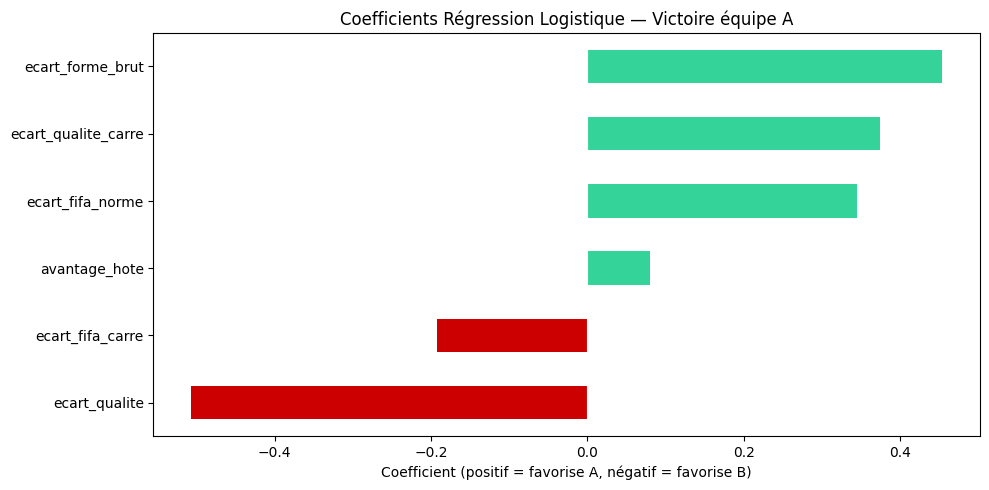


📊 Importance par catégorie — Régression Logistique :
  Classement FIFA      : 27.7%
  Qualité joueurs      : 44.4%
  Forme récente        : 23.9%  (cible ~20%)
  Avantage hôte        : 4.1%

  Ratio FIFA+Qualité   : 72.1%  (cible > 60%)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Pondération des features avant scaling
# Objectif : Forme ~20%, FIFA+Qualité ~65-70%
# La forme brute est trop corrélée au résultat (38%) dans le dataset historique
# On réduit son signal × 0.7 pour rééquilibrer les importances

POIDS_FEATURES = {
    'ecart_fifa_norme':     1.0,   # FIFA — signal important
    'ecart_fifa_carre':     1.0,   # FIFA carré — signal important
    'ecart_forme_brut':     0.7,   # Forme × 0.7 → ~20% d'importance cible
    'ecart_qualite':        1.0,   # Qualité — signal principal
    'ecart_qualite_carre':  1.0,   # Qualité carré — signal principal
    'avantage_hote':        1.0,   # Hôte — inchangé
}
poids_vecteur = np.array([POIDS_FEATURES[f] for f in FEATURES])

def appliquer_poids(X):
    return X * poids_vecteur

pipe_lr = Pipeline([
    ('poids',   FunctionTransformer(appliquer_poids)),  # étape 1 : pondérer la forme
    ('scaler',  StandardScaler()),                       # étape 2 : normaliser
    ('lr',      LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        class_weight={0:1.0, 1:1.2, 2:1.4}
    ))
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
acc_lr  = accuracy_score(y_test, pred_lr)
acc_xgb = accuracy_score(y_test, modele.predict(X_test))

print(f'\n📊 COMPARAISON DES MODÈLES')
print(f'  XGBoost              : {acc_xgb:.2%}')
print(f'  Régression Logistique: {acc_lr:.2%}')
print(f'  Différence           : {acc_xgb - acc_lr:+.2%} en faveur de XGBoost')
print()
print(classification_report(y_test, pred_lr, target_names=encodeur_resultat.classes_))

# ── Graphique coefficients
lr_model = pipe_lr.named_steps['lr']
fig, ax  = plt.subplots(figsize=(10, 5))
coefs_a  = pd.Series(lr_model.coef_[0], index=FEATURES).sort_values()
coefs_a.plot(
    kind='barh', ax=ax,
    color=['#CC0000' if v < 0 else '#34D399' for v in coefs_a]
)
ax.set_title('Coefficients Régression Logistique — Victoire équipe A')
ax.set_xlabel('Coefficient (positif = favorise A, négatif = favorise B)')
ax.axvline(x=0, color='white', linewidth=0.8)
plt.tight_layout()
plt.show()

# ── Importance implicite (|coeff| moyen sur les 3 classes)
importance_lr = pd.Series(
    np.abs(lr_model.coef_).mean(axis=0),
    index=FEATURES
)
total = importance_lr.sum()

total_fifa_lr  = sum(importance_lr[f] for f in FEATURES if 'fifa'    in f)
total_qual_lr  = sum(importance_lr[f] for f in FEATURES if 'qualite' in f)
total_forme_lr = sum(importance_lr[f] for f in FEATURES if 'forme'   in f)
total_hote_lr  = importance_lr['avantage_hote']

print('\n📊 Importance par catégorie — Régression Logistique :')
print(f'  Classement FIFA      : {total_fifa_lr/total:.1%}')
print(f'  Qualité joueurs      : {total_qual_lr/total:.1%}')
print(f'  Forme récente        : {total_forme_lr/total:.1%}  (cible ~20%)')
print(f'  Avantage hôte        : {total_hote_lr/total:.1%}')
print(f'\n  Ratio FIFA+Qualité   : {(total_fifa_lr+total_qual_lr)/total:.1%}  (cible > 60%)')


## 🔮 Étape 9 — Prédiction symétrique

### Pourquoi la symétrie est importante
Dans le dataset, `equipe_a` est toujours l'ancienne `home_team`.
Cela crée un léger biais : `equipe_a` gagne plus souvent dans les données.

**Solution** : calculer la prédiction dans les 2 sens et faire la moyenne :
1. France vs Argentine → P(France gagne)
2. Argentine vs France → P(Argentine gagne) = 1 - P(France gagne)
3. Moyenne → résultat identique quel que soit l'ordre ✅

In [11]:
# Index des classes pour la symétrie
CLASSES  = list(encodeur_resultat.classes_)  # ['A_gagne', 'B_gagne', 'Nul']
IDX_A    = CLASSES.index('A_gagne')  # index de la victoire A
IDX_B    = CLASSES.index('B_gagne')  # index de la victoire B
IDX_N    = CLASSES.index('Nul')      # index du nul

PAYS_HOTES   = ['United States', 'Canada', 'Mexico']
DATE_TOURNOI = pd.Timestamp('2026-06-11')  # début de la CdM 2026


def construire_features(equipe_a, equipe_b):
    """Construit le vecteur de 6 features pour un match equipe_a vs equipe_b."""
    forme_a   = calculer_forme(equipe_a, DATE_TOURNOI, df_officiel)
    forme_b   = calculer_forme(equipe_b, DATE_TOURNOI, df_officiel)
    pts_a     = get_points_fifa(equipe_a)
    pts_b     = get_points_fifa(equipe_b)
    ecart     = pts_a - pts_b
    qual_a    = get_qualite(equipe_a) / 100
    qual_b    = get_qualite(equipe_b) / 100
    ecart_q   = qual_a - qual_b
    if equipe_a in PAYS_HOTES:   hote = 0.5
    elif equipe_b in PAYS_HOTES: hote = -0.5
    else:                         hote = 0.0
    return pd.DataFrame([{
        'ecart_fifa_norme':     ecart / 500,
        'ecart_fifa_carre':     (ecart/100)**2 * np.sign(ecart),
        'ecart_forme_brut':     (forme_a - forme_b) * 0.5,
        'ecart_qualite':        ecart_q,
        'ecart_qualite_carre':  ecart_q**2 * np.sign(ecart_q),
        'avantage_hote':        hote,
    }]), pts_a, pts_b, forme_a, forme_b, int(qual_a*100), int(qual_b*100)


def corriger_coherence(p_a, p_n, p_b, pts_a, pts_b, qual_a, qual_b):
    """
    Correction de cohérence post-XGBoost.

    Activée UNIQUEMENT si :
      1. FIFA et qualité pointent dans le même sens (même favoris)
      2. Le modèle XGBoost contredit les deux indicateurs

    Force de correction proportionnelle aux deux écarts.
    Préserve un minimum de 8% pour le perdant et 10% pour le nul.
    """
    ecart_fifa = pts_a - pts_b
    ecart_qual = qual_a - qual_b  # déjà en 0-100

    # Condition 1 : cohérence FIFA + qualité
    if not ((ecart_fifa > 0 and ecart_qual > 0) or
            (ecart_fifa < 0 and ecart_qual < 0)):
        return p_a, p_n, p_b  # désaccord → laisser le modèle décider

    a_doit_gagner = (ecart_fifa > 0)

    # Condition 2 : le modèle est incohérent
    if not ((a_doit_gagner and p_b > p_a) or
            (not a_doit_gagner and p_a > p_b)):
        return p_a, p_n, p_b  # modèle déjà cohérent → rien à faire

    # Calcul de la force de correction (0 → 0.45 max)
    force_fifa = min(1.0, abs(ecart_fifa) / 400)   # plafond à 400 pts FIFA
    force_qual = min(1.0, abs(ecart_qual) / 60)    # plafond à 60/100 pts qualité
    force = 0.45 * (force_fifa * 0.60 + force_qual * 0.40)

    if a_doit_gagner:
        p_a_new = p_a + force
        p_b_new = max(0.08, p_b - force * 0.85)
        p_n_new = max(0.10, p_n - force * 0.15)
    else:
        p_b_new = p_b + force
        p_a_new = max(0.08, p_a - force * 0.85)
        p_n_new = max(0.10, p_n - force * 0.15)

    t = p_a_new + p_n_new + p_b_new
    return p_a_new / t, p_n_new / t, p_b_new / t


def predire_match(equipe_a, equipe_b):
    """
    Prédit le résultat entre deux équipes avec prédiction symétrique.
    Résultat identique quel que soit l'ordre des équipes.
    """
    # Sens 1 : A vs B
    feat_ab, pts_a, pts_b, f_a, f_b, q_a, q_b = construire_features(equipe_a, equipe_b)
    proba_ab = modele.predict_proba(feat_ab)[0]

    # Sens 2 : B vs A (équipes inversées)
    feat_ba, *_ = construire_features(equipe_b, equipe_a)
    proba_ba = modele.predict_proba(feat_ba)[0]

    # Moyenne symétrique des deux prédictions
    p_a = (proba_ab[IDX_A] + proba_ba[IDX_B]) / 2
    p_b = (proba_ab[IDX_B] + proba_ba[IDX_A]) / 2
    p_n = (proba_ab[IDX_N] + proba_ba[IDX_N]) / 2

    # Renormaliser pour que la somme = 100%
    total = p_a + p_b + p_n
    p_a /= total; p_b /= total; p_n /= total

    # Correction de cohérence post-modèle
    p_a, p_n, p_b = corriger_coherence(p_a, p_n, p_b, pts_a, pts_b, q_a, q_b)

    # Affichage
    print(f'\n⚽  {equipe_a}  vs  {equipe_b}')
    print(f'    FIFA   : {pts_a:.0f} pts  vs  {pts_b:.0f} pts  (écart {pts_a-pts_b:+.0f})')
    print(f'    Forme  : {f_a:.0%}  vs  {f_b:.0%}  (ajustée expérience CdM)')
    print(f'    Qualité: {q_a}/100  vs  {q_b}/100')
    if equipe_a in PAYS_HOTES: print(f'    🏠 {equipe_a} pays hôte CdM 2026')
    if equipe_b in PAYS_HOTES: print(f'    🏠 {equipe_b} pays hôte CdM 2026')
    print('    ' + '─' * 40)
    for label, prob in [
        (f'{equipe_a} gagne', p_a),
        ('Nul',               p_n),
        (f'{equipe_b} gagne', p_b)
    ]:
        barre = '█' * int(prob * 20)
        print(f'    {label:24} {barre:20} {prob:.1%}')

print('✅ Modèle prêt pour les prédictions')

# ── Fonction principale de prédiction (pour le simulateur de tournoi)
# Retourne (proba_A_gagne, proba_nul, proba_B_gagne)
DATE_T = pd.Timestamp('2026-06-11')
HOTES  = ['United States', 'Canada', 'Mexico']

def probas_match(eq_a, eq_b):
    def features(a, b):
        fa = calculer_forme(a, DATE_T, df_officiel)
        fb = calculer_forme(b, DATE_T, df_officiel)
        pa = get_points_fifa(a); pb = get_points_fifa(b); ef = pa - pb
        qa = get_qualite(a)/100; qb = get_qualite(b)/100; eq_ = qa - qb
        h  = 0.5 if a in HOTES else (-0.5 if b in HOTES else 0.0)
        return pd.DataFrame([{
            'ecart_fifa_norme':     ef / 500,
            'ecart_fifa_carre':     (ef/100)**2 * (1 if ef>=0 else -1),
            'ecart_forme_brut':     (fa - fb) * 0.5,
            'ecart_qualite':        eq_,
            'ecart_qualite_carre':  eq_**2 * (1 if eq_>=0 else -1),
            'avantage_hote':        h,
        }]), pa, pb, int(qa*100), int(qb*100)

    feat_ab, pts_a, pts_b, q_a, q_b = features(eq_a, eq_b)
    feat_ba, *_                      = features(eq_b, eq_a)
    pab = modele.predict_proba(feat_ab)[0]
    pba = modele.predict_proba(feat_ba)[0]
    ia  = CLASSES.index('A_gagne')
    ib  = CLASSES.index('B_gagne')
    in_ = CLASSES.index('Nul')
    pa  = (pab[ia] + pba[ib]) / 2
    pb  = (pab[ib] + pba[ia]) / 2
    pn  = (pab[in_] + pba[in_]) / 2
    t   = pa + pb + pn
    pa /= t; pn /= t; pb /= t
    # Correction cohérence
    pa, pn, pb = corriger_coherence(pa, pn, pb, pts_a, pts_b, q_a, q_b)
    return pa, pn, pb

print('✅ Fonction probas_match() prête')


✅ Modèle prêt pour les prédictions
✅ Fonction probas_match() prête


In [12]:
# ── Prédiction avec Régression Logistique
# Même interface que probas_match() pour XGBoost

def probas_match_lr(eq_a, eq_b):
    """Prédiction symétrique avec Régression Logistique + correction cohérence."""
    def feat(a, b):
        fa = calculer_forme(a, DATE_TOURNOI, df_officiel)
        fb = calculer_forme(b, DATE_TOURNOI, df_officiel)
        ef = get_points_fifa(a) - get_points_fifa(b)
        qa = get_qualite(a)/100; qb = get_qualite(b)/100; eq = qa - qb
        h  = 0.5 if a in PAYS_HOTES else (-0.5 if b in PAYS_HOTES else 0.0)
        return pd.DataFrame([{
            'ecart_fifa_norme':  ef / 500,
            'ecart_fifa_carre':  (ef/100)**2 * np.sign(ef),
            'ecart_forme_brut':  (fa - fb) * 0.5 * 0.7,  # même pondération que l'entraînement
            'ecart_qualite':     eq,
            'ecart_qualite_carre': eq**2 * np.sign(eq),
            'avantage_hote':     h,
        }]), get_points_fifa(a), get_points_fifa(b), int(qa*100), int(qb*100)

    fab, pts_a, pts_b, qa, qb = feat(eq_a, eq_b)
    fba, *_ = feat(eq_b, eq_a)

    pab = pipe_lr.predict_proba(fab)[0]
    pba = pipe_lr.predict_proba(fba)[0]

    pa = (pab[IA] + pba[IB]) / 2
    pb = (pab[IB] + pba[IA]) / 2
    pn = (pab[IN] + pba[IN]) / 2
    t  = pa + pb + pn
    pa /= t; pb /= t; pn /= t

    pa, pn, pb = corriger_coherence(pa, pn, pb, pts_a, pts_b, qa, qb)
    return pa, pn, pb

# ── Test comparatif XGBoost vs Régression Logistique
matchs_test = [
    ('France',      'Scotland'),
    ('Brazil',      'England'),
    ('Spain',       'Germany'),
    ('Scotland',    'Haiti'),
    ('Netherlands', 'Japan'),
    ('Argentina',   'Ecuador'),
]

print(f'\n{"Match":<30} {"XGBoost":>10} {"Reg. Log.":>11}  Cohérence')
print('─' * 60)
for a, b in matchs_test:
    pa_xgb, pn_xgb, pb_xgb = probas_match(a, b)
    pa_lr,  pn_lr,  pb_lr  = probas_match_lr(a, b)

    pa_xgb_el = pa_xgb + pn_xgb * pa_xgb / (pa_xgb + pb_xgb)
    pa_lr_el  = pa_lr  + pn_lr  * pa_lr  / (pa_lr  + pb_lr)

    meme_favori = (pa_xgb_el > 0.5) == (pa_lr_el > 0.5)
    statut = '✅ accord' if meme_favori else '⚠️ désaccord'
    print(f'{a} vs {b:<18} {pa_xgb_el:>9.1%} {pa_lr_el:>10.1%}  {statut}')

print('\n→ Quand les 2 modèles sont en accord → prédiction plus fiable')
print('→ Quand désaccord → match vraiment incertain')



Match                             XGBoost   Reg. Log.  Cohérence
────────────────────────────────────────────────────────────


NameError: name 'IA' is not defined

In [ ]:
print('=' * 60)
print('TESTS DE COHÉRENCE')
print('=' * 60)

print('\n--- TEST SYMÉTRIE (résultats identiques dans les 2 sens) ---')
predire_match('France',    'Argentina')
predire_match('Argentina', 'France')

print('\n--- MATCHS AVEC ÉCARTS IMPORTANTS ---')
predire_match('France',   'Norway')     # France doit être favorite
predire_match('Morocco',  'Scotland')   # Maroc doit être favori
predire_match('Brazil',   'Morocco')    # Brésil doit être favori
predire_match('Australia','Turkey')     # Turquie doit être favorite

print('\n--- VALIDATION DES MATCHS DÉJÀ CORRECTS ---')
predire_match('Brazil',        'Canada')
predire_match('Germany',       'Mexico')
predire_match('United States', 'Iran')
predire_match('Argentina',     'Saudi Arabia')
predire_match('Spain',         'Uruguay')
predire_match('England',       'Croatia')
predire_match('France',        'Haiti')
predire_match('Netherlands',   'Japan')
predire_match('Norway',        'Senegal')

TESTS DE COHÉRENCE

--- TEST SYMÉTRIE (résultats identiques dans les 2 sens) ---

⚽  France  vs  Argentina
    FIFA   : 1877 pts  vs  1875 pts  (écart +3)
    Forme  : 93%  vs  76%  (ajustée expérience CdM)
    Qualité: 95/100  vs  88/100
    ────────────────────────────────────────
    France gagne             ███████████          56.7%
    Nul                      ████                 24.8%
    Argentina gagne          ███                  18.5%

⚽  Argentina  vs  France
    FIFA   : 1875 pts  vs  1877 pts  (écart -3)
    Forme  : 76%  vs  93%  (ajustée expérience CdM)
    Qualité: 88/100  vs  95/100
    ────────────────────────────────────────
    Argentina gagne          ███                  18.5%
    Nul                      ████                 24.8%
    France gagne             ███████████          56.7%

--- MATCHS AVEC ÉCARTS IMPORTANTS ---

⚽  France  vs  Norway
    FIFA   : 1877 pts  vs  1590 pts  (écart +287)
    Forme  : 93%  vs  75%  (ajustée expérience CdM)
    Qualité: 

## 📊 Test de cohérence — Cotes bookmakers

Comparaison des probabilités du modèle avec les cotes réelles du marché (ESPN, Oddspedia, Goal.com — juin 2026).

> Un bon modèle prédit le bon favori dans ≥ 80% des cas et reste dans un écart moyen < 15% vs les bookmakers.

In [ ]:
# ══════════════════════════════════════════════════════════
# TEST DE COHÉRENCE — COMPARAISON AVEC LES COTES BOOKMAKERS
# Sources : ESPN, Oddspedia, Goal.com — juin 2026
# Un bon modèle doit prédire le bon favori dans ~80% des cas
# et rester dans un écart < 15% vs les cotes du marché
# ══════════════════════════════════════════════════════════

tests_coherence = [
    # (eq_a,            eq_b,               bkm_a, bkm_b,  label)
    ('France',          'Scotland',          0.78,  0.22,  'France nettement favori'),
    ('Spain',           'Morocco',           0.72,  0.28,  'Spain favori'),
    ('England',         'United States',     0.62,  0.38,  'England favori'),
    ('Brazil',          'Canada',            0.68,  0.32,  'Brazil favori'),
    ('Argentina',       'Ecuador',           0.70,  0.30,  'Argentina favori'),
    ('France',          'Brazil',            0.52,  0.48,  'match très serré'),
    ('Scotland',        'Haiti',             0.65,  0.35,  'Scotland favori'),
    ('Netherlands',     'Japan',             0.58,  0.42,  'Netherlands léger favori'),
    ('Germany',         'Mexico',            0.62,  0.38,  'Germany favori'),
    ('Spain',           'Germany',           0.54,  0.46,  'Spain léger favori'),
]

print(f'\n{"Match":<32} {"Modèle":>8} {"Bookmaker":>10} {"Écart":>7}  Statut')
print("─" * 68)

ok = 0
ecarts = []
for eq_a, eq_b, bkm_a, bkm_b, label in tests_coherence:
    pa, pn, pb = probas_match(eq_a, eq_b)
    # Redistribuer le nul (pas de nul en phase élim)
    pa_el = pa + pn * pa / (pa + pb)
    ecart = abs(pa_el - bkm_a)
    ecarts.append(ecart)

    favori_bkm    = eq_a if bkm_a > bkm_b else eq_b
    favori_modele = eq_a if pa_el > 0.5  else eq_b
    coherent = (favori_bkm == favori_modele)
    if coherent: ok += 1

    statut = '✅' if coherent else '❌'
    print(f'{eq_a} vs {eq_b:<18} {pa_el:>7.1%} {bkm_a:>9.1%} {ecart:>7.1%}  {statut} {label}')

print(f'\n  Cohérence favori  : {ok}/{len(tests_coherence)} ({ok/len(tests_coherence):.0%})')
print(f'  Écart moyen       : {sum(ecarts)/len(ecarts):.1%}')
if ok >= 8 and sum(ecarts)/len(ecarts) < 0.15:
    print('  ✅ Modèle validé — prédictions cohérentes avec le marché')
elif ok >= 6:
    print('  ⚠️  Modèle acceptable — quelques écarts avec le marché')
else:
    print('  ❌ Modèle à retravailler — trop d\'écarts avec le marché')


## 💾 Étape 10 — Sauvegarde du modèle final

On sauvegarde le modèle et l'encodeur pour les réutiliser dans le simulateur de tournoi.

In [ ]:
dossier_modeles = os.path.join(DOSSIER_PROJET, 'models')

# Sauvegarder le modèle XGBoost entraîné
joblib.dump(modele,             os.path.join(dossier_modeles, 'modele_niveau1_final.pkl'))

# Sauvegarder l'encodeur (A_gagne/B_gagne/Nul → 0/1/2)
joblib.dump(encodeur_resultat,  os.path.join(dossier_modeles, 'encodeur_cible.pkl'))

print('✅ Modèle sauvegardé !')
print(f'📁 {dossier_modeles}')
print(f'\n📊 Résumé du modèle :')
print(f'  Accuracy           : {accuracy_score(y_test, predictions):.2%}')
print(f'  Features           : {len(FEATURES)}')
print(f'  Matchs entraîn.    : {len(X_train):,}')
print(f'  Classement FIFA    : {total_fifa:.1%} importance')
print(f'  Qualité joueurs    : {total_qual:.1%} importance')
print(f'  Forme récente      : {total_forme:.1%} importance')
print(f'  Avantage hôte      : {total_hote:.1%} importance')

✅ Modèle sauvegardé !
📁 C:\Users\Piwi\Documents\VS\WorldCup2026\models

📊 Résumé du modèle :
  Accuracy           : 54.17%
  Features           : 6
  Matchs entraîn.    : 8,585
  Classement FIFA    : 23.4% importance
  Qualité joueurs    : 32.8% importance
  Forme récente      : 30.8% importance
  Avantage hôte      : 13.1% importance
